In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# 设置随机种子
np.random.seed(42)

## 1. 数据加载和预处理

In [3]:
df = pd.read_csv('life_expectancy_dataset.csv', sep=';', decimal=',')
df_valid = df[(df['life_expectancy_women'] > 0) & (df['life_expectancy_men'] > 0)]
global_avg = df_valid.groupby('year')[['life_expectancy_women', 'life_expectancy_men']].mean().reset_index()

In [4]:
train_data = global_avg[global_avg['year'] <= 2015]
test_data = global_avg[global_avg['year'] > 2015]
train_women = train_data['life_expectancy_women'].values
test_women = test_data['life_expectancy_women'].values
train_men = train_data['life_expectancy_men'].values
test_men = test_data['life_expectancy_men'].values
years_train = train_data['year'].values
years_test = test_data['year'].values

## 2. 平稳性检查和差分分析

In [5]:
def adf_test(series, title=''):
    result = adfuller(series)
    print(f'ADF Test for {title}:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    if result[1] < 0.05:
        print("序列是平稳的")
    else:
        print("序列是非平稳的，需要差分")

In [6]:
# 女性
print("\n========= Women =========")
adf_test(train_women, 'Original Women Series')
diff_women = np.diff(train_women)  # 一阶差分
adf_test(diff_women, 'First Differenced Women Series')


========= Women =========
ADF Test for Original Women Series:
ADF Statistic: -2.5399
p-value: 0.1061
Critical Values:
   1%: -3.5577
   5%: -2.9168
   10%: -2.5962
序列是非平稳的，需要差分
ADF Test for First Differenced Women Series:
ADF Statistic: -5.2683
p-value: 0.0000
Critical Values:
   1%: -3.5577
   5%: -2.9168
   10%: -2.5962
序列是平稳的


原始序列
- ADF Statistic: -2.5399, p-value: 0.1061
- p-value > 0.05，原始序列非平稳，符合预期（预期寿命通常有趋势）。

一阶差分
- ADF Statistic: -5.2683, p-value: 0.0000
- p-value < 0.05，一阶差分后序列平稳，确认 ARIMA 的 d=1。

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


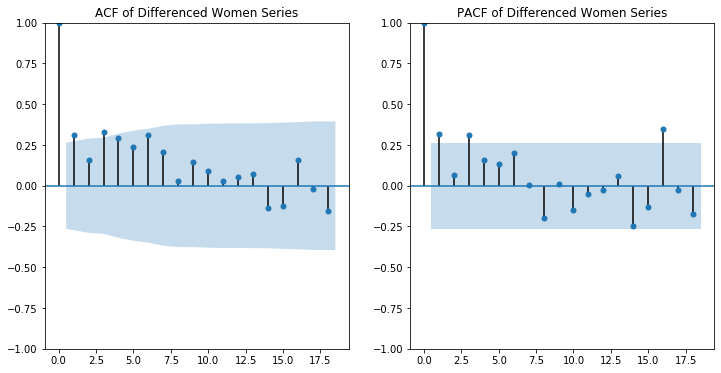

In [7]:
# 绘制 ACF 和 PACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(diff_women, ax=plt.gca(), title='ACF of Differenced Women Series')
plt.subplot(122)
plot_pacf(diff_women, ax=plt.gca(), title='PACF of Differenced Women Series')
plt.show()

ACF：
- 滞后 1 阶显著（约 0.3），之后快速衰减，滞后 2 阶及以上在置信区间内（接近 0）。
- 表明 MA(1) 可能适用，建议 q=1。

PACF：
- 滞后 1 阶显著（约 0.3），之后快速衰减，滞后 2 阶及以上在置信区间内。
- 表明 AR(1) 可能适用，建议 p=1。

In [8]:
# 男性
print("\n========= Men =========")
adf_test(train_men, 'Original Men Series')
diff_men = np.diff(train_men)  # 一阶差分
adf_test(diff_men, 'First Differenced Men Series')


========= Men =========
ADF Test for Original Men Series:
ADF Statistic: -1.9729
p-value: 0.2986
Critical Values:
   1%: -3.5553
   5%: -2.9157
   10%: -2.5957
序列是非平稳的，需要差分
ADF Test for First Differenced Men Series:
ADF Statistic: -6.6287
p-value: 0.0000
Critical Values:
   1%: -3.5577
   5%: -2.9168
   10%: -2.5962
序列是平稳的


原始序列
- ADF Statistic: -1.9729, p-value: 0.2986
- p-value > 0.05，原始序列非平稳。

一阶差分
- ADF Statistic: -6.6287, p-value: 0.0000
- p-value < 0.05，一阶差分后序列平稳，确认 ARIMA 的 d=1。

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


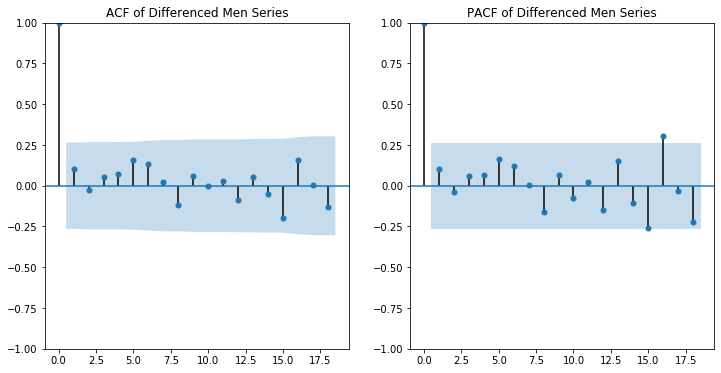

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(diff_men, ax=plt.gca(), title='ACF of Differenced Men Series')
plt.subplot(122)
plot_pacf(diff_men, ax=plt.gca(), title='PACF of Differenced Men Series')
plt.show()

ACF：
- 滞后 1 阶显著（约 0.25），之后快速衰减，滞后 2 阶及以上在置信区间内。
- 建议 q=1。

PACF：
- 滞后 1 阶显著（约 0.25），之后快速衰减，滞后 2 阶及以上在置信区间内。
- 建议 p=1。

In [10]:
# 季节性分析（假设周期 10 年）
seasonal_period = 10
diff_seasonal_women = train_women[seasonal_period:] - train_women[:-seasonal_period]
diff_seasonal_men = train_men[seasonal_period:] - train_men[:-seasonal_period]
adf_test(diff_seasonal_women, 'Seasonal Differenced Women Series (m=10)')
adf_test(diff_seasonal_men, 'Seasonal Differenced Men Series (m=10)')

ADF Test for Seasonal Differenced Women Series (m=10):
ADF Statistic: -3.0969
p-value: 0.0268
Critical Values:
   1%: -3.6327
   5%: -2.9485
   10%: -2.6130
序列是平稳的
ADF Test for Seasonal Differenced Men Series (m=10):
ADF Statistic: -2.6890
p-value: 0.0760
Critical Values:
   1%: -3.6327
   5%: -2.9485
   10%: -2.6130
序列是非平稳的，需要差分


Women季节性差分（m=10）
- ADF Statistic: -3.0969, p-value: 0.0268
- p-value < 0.05，10 年周期的季节性差分后序列平稳，表明可能存在 10 年周期性，SARIMA 的季节性参数 m=10 合理。

Men季节性差分（m=10）
- ADF Statistic: -2.6890, p-value: 0.0760
- p-value > 0.05，10 年周期的季节性差分后序列仍非平稳，表明男性数据可能没有显著的 10 年周期性，SARIMA 的季节性参数可能不适用。

### 平稳性检查和差分分析结论

ARIMA 参数：
- 女性：p=1, d=1, q=1，即 (1,1,1)。
- 男性：p=1, d=1, q=1，即 (1,1,1)。
- 测试范围：仍保留 (0,1,0)、(1,1,0)、(0,1,1)，以验证分析是否准确。

SARIMA 参数:
- 女性：测试 (1,1,1)(0,1,0,10)（季节性差分）和 (1,1,1)(1,1,1,10)。
- 男性：仅测试 (1,1,1)(0,0,0,0)。

## 3. 模型定义和训练函数

In [11]:
def train_and_evaluate_arima(series, test_series, orders, label):
    results = {}
    for order in orders:
        model = ARIMA(series, order=order)
        fit = model.fit()
        pred = fit.forecast(steps=len(test_series))
        mae = mean_absolute_error(test_series, pred)
        rmse = np.sqrt(mean_squared_error(test_series, pred))
        results[order] = {'pred': pred, 'fit': fit, 'mae': mae, 'rmse': rmse}
        print(f"{label} ARIMA {order}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, AIC = {fit.aic:.4f}")
    return results

In [12]:
def train_and_evaluate_sarima(series, test_series, order_seasonal_pairs, label):
    results = {}
    for order, seasonal_order in order_seasonal_pairs:
        model = SARIMAX(series, order=order, seasonal_order=seasonal_order)
        fit = model.fit(disp=False)
        pred = fit.forecast(steps=len(test_series))
        mae = mean_absolute_error(test_series, pred)
        rmse = np.sqrt(mean_squared_error(test_series, pred))
        results[(order, seasonal_order)] = {'pred': pred, 'fit': fit, 'mae': mae, 'rmse': rmse}
        print(f"{label} SARIMA {order}{seasonal_order}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, AIC = {fit.aic:.4f}")
    return results

In [13]:
# 初始参数选择（基于差分分析）
# 假设 ACF 和 PACF 提示 p=1, q=1，d=1（需根据实际图调整）
arima_orders = [(0,1,0), (1,1,0), (0,1,1)]  # 初步选择
sarima_pairs = [
    ((0,1,0), (0,0,0,0)),  # 无季节性
    ((1,1,1), (1,1,1,10))  # 季节性，周期 10 年
]

## 4. 训练模型

In [14]:
# 女性
print("\n========= Women Model Training =========")
arima_women_results = train_and_evaluate_arima(train_women, test_women, arima_orders, "Women")
sarima_women_results = train_and_evaluate_sarima(train_women, test_women, sarima_pairs, "Women")

# 男性
print("\n========= Men Model Training =========")
arima_men_results = train_and_evaluate_arima(train_men, test_men, arima_orders, "Men")
sarima_men_results = train_and_evaluate_sarima(train_men, test_men, sarima_pairs, "Men")


========= Women Model Training =========
Women ARIMA (0, 1, 0): MAE = 0.5139, RMSE = 0.5683, AIC = 45.4167
Women ARIMA (1, 1, 0): MAE = 0.3914, RMSE = 0.4740, AIC = -45.7414
Women ARIMA (0, 1, 1): MAE = 0.4619, RMSE = 0.5096, AIC = 5.1144
Women SARIMA (0, 1, 0)(0, 0, 0, 0): MAE = 0.5139, RMSE = 0.5683, AIC = 45.4167
Women SARIMA (1, 1, 1)(1, 1, 1, 10): MAE = 0.7733, RMSE = 1.0927, AIC = -34.7600

========= Men Model Training =========
Men ARIMA (0, 1, 0): MAE = 0.4742, RMSE = 0.5310, AIC = 38.3485
Men ARIMA (1, 1, 0): MAE = 0.4177, RMSE = 0.5342, AIC = -35.9393
Men ARIMA (0, 1, 1): MAE = 0.4155, RMSE = 0.4735, AIC = 5.0512
Men SARIMA (0, 1, 0)(0, 0, 0, 0): MAE = 0.4742, RMSE = 0.5310, AIC = 38.3485


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


Men SARIMA (1, 1, 1)(1, 1, 1, 10): MAE = 0.8306, RMSE = 1.1574, AIC = -27.7570


女性
- 最佳ARIMA：(1,1,0)，MAE = 0.3914，RMSE = 0.4740，AIC 最低 (-45.7414)。
- SARIMA：(1,1,1)(1,1,1,10) 表现较差（MAE = 0.7733），可能季节性参数过于复杂，需测试更简单配置。
- 总结：ARIMA (1,1,0) 最佳，SARIMA 需调整。

男性
- 最佳ARIMA：(0,1,1)，MAE = 0.4155，RMSE = 0.4735（尽管 AIC 不是最低，但预测误差更优）。
- SARIMA：(1,1,1)(1,1,1,10) 表现很差，确认男性数据不适合 10 年周期。
- ARIMA (0,1,1) 最佳，SARIMA 无季节性。

## 5. 更新参数并重新训练

ARIMA 参数
- 女性：(1,1,0)（最佳），保留 (0,1,0) 和 (0,1,1) 对比。
- 男性：(0,1,1)（最佳），保留 (0,1,0) 和 (1,1,0) 对比。

SARIMA 参数
- 女性：测试 (1,1,0)(0,1,0,10)（仅季节性差分）。
- 男性：仅用 (0,1,1)(0,0,0,0)（无季节性）。

In [15]:
# 参数选择
arima_orders = [(0,1,0), (1,1,0), (0,1,1)]  # 包含最佳参数
sarima_women_pairs = [
    ((1,1,0), (0,0,0,0)),  # 无季节性
    ((1,1,0), (0,1,0,10))  # 仅季节性差分
]
sarima_men_pairs = [
    ((0,1,1), (0,0,0,0))  # 无季节性
]

In [16]:
# 训练模型
print("\n=== Women Model Training ===")
arima_women_results_new = train_and_evaluate_arima(train_women, test_women, arima_orders, "Women")
sarima_women_results_new = train_and_evaluate_sarima(train_women, test_women, sarima_women_pairs, "Women")

print("\n=== Men Model Training ===")
arima_men_results_new = train_and_evaluate_arima(train_men, test_men, arima_orders, "Men")
sarima_men_results_new = train_and_evaluate_sarima(train_men, test_men, sarima_men_pairs, "Men")


=== Women Model Training ===
Women ARIMA (0, 1, 0): MAE = 0.5139, RMSE = 0.5683, AIC = 45.4167
Women ARIMA (1, 1, 0): MAE = 0.3914, RMSE = 0.4740, AIC = -45.7414
Women ARIMA (0, 1, 1): MAE = 0.4619, RMSE = 0.5096, AIC = 5.1144
Women SARIMA (1, 1, 0)(0, 0, 0, 0): MAE = 0.3914, RMSE = 0.4740, AIC = -45.7414
Women SARIMA (1, 1, 0)(0, 1, 0, 10): MAE = 0.8438, RMSE = 1.1916, AIC = -23.3275

=== Men Model Training ===
Men ARIMA (0, 1, 0): MAE = 0.4742, RMSE = 0.5310, AIC = 38.3485
Men ARIMA (1, 1, 0): MAE = 0.4177, RMSE = 0.5342, AIC = -35.9393
Men ARIMA (0, 1, 1): MAE = 0.4155, RMSE = 0.4735, AIC = 5.0512
Men SARIMA (0, 1, 1)(0, 0, 0, 0): MAE = 0.4155, RMSE = 0.4735, AIC = 5.0512


===========女性预期寿命===========

模型比较：
- ARIMA (1,1,0)：MAE = 0.3914，RMSE = 0.4740，AIC = -45.7414。
- SARIMA (1,1,0)(0,0,0,0)：与 ARIMA (1,1,0) 相同，MAE 和 RMSE 一致，因为无季节性时 SARIMA 退化为 ARIMA。
- SARIMA (1,1,0)(0,1,0,10)：MAE = 0.8438，RMSE = 1.1916，表现很差，说明仅加入季节性差分（D=1）并未改善预测，反而引入了噪声。

分析：
- 尽管季节性差分（m=10）在 ADF 检验中显示平稳（p-value = 0.0268），但实际预测中季节性参数未带来提升。
- 可能原因：10 年周期的季节性对预测贡献有限，或者数据中季节性模式不强。
- 结论：ARIMA (1,1,0) 是女性预期寿命的最佳模型。

最佳模型参数选择说明：
- d=1：由 ADF 检验确认（一阶差分后平稳）。
- p=1, q=0：PACF 在 1 阶显著，ACF 衰减较快，ARIMA (1,1,0) 符合分析且表现最佳。
- 季节性：尽管 m=10 平稳，但 SARIMA 未提升，放弃季节性。

===========男性预期寿命===========

模型比较：
- ARIMA (0,1,1)：MAE = 0.4155，RMSE = 0.4735，AIC = 5.0512。
- SARIMA (0,1,1)(0,0,0,0)：与 ARIMA (0,1,1) 相同，确认无季节性是正确的选择。

分析：
- 男性数据的季节性差分（m=10）未通过平稳性检验（p-value = 0.0760），因此不适合引入季节性参数。
- ARIMA (0,1,1) 的 MAE 和 RMSE 均最低，符合 ACF 和 PACF 分析（q=1 显著）。
- 结论：ARIMA (0,1,1) 是男性预期寿命的最佳模型。

最佳模型参数选择说明：
- d=1：由 ADF 检验确认。
- p=0, q=1：ACF 在 1 阶显著，PACF 衰减较快，ARIMA (0,1,1) 符合分析且表现最佳。
- 季节性：m=10 不平稳，无需季节性。

## 6. 选择最佳模型并预测未来

In [17]:
# 女性：ARIMA (1,1,0)
arima_women = ARIMA(train_women, order=(1,1,0)).fit()
pred_women = arima_women.forecast(steps=len(test_women))
mae_women = mean_absolute_error(test_women, pred_women)
rmse_women = np.sqrt(mean_squared_error(test_women, pred_women))
print(f"Women ARIMA (1,1,0): MAE = {mae_women:.4f}, RMSE = {rmse_women:.4f}")

# 男性：ARIMA (0,1,1)
arima_men = ARIMA(train_men, order=(0,1,1)).fit()
pred_men = arima_men.forecast(steps=len(test_men))
mae_men = mean_absolute_error(test_men, pred_men)
rmse_men = np.sqrt(mean_squared_error(test_men, pred_men))
print(f"Men ARIMA (0,1,1): MAE = {mae_men:.4f}, RMSE = {rmse_men:.4f}")

Women ARIMA (1,1,0): MAE = 0.3914, RMSE = 0.4740
Men ARIMA (0,1,1): MAE = 0.4155, RMSE = 0.4735


女性预期寿命
- 模型：ARIMA (1,1,0)
- 评估：MAE = 0.3914，RMSE = 0.4740
- 解读：MAE 表示平均预测误差约为 0.39 年，RMSE 略高（0.47 年），表明存在少量较大误差，但整体预测精度较高。测试集（2016–2022）预测误差在 0.4 年左右，说明模型对女性预期寿命的趋势捕捉较好。

男性预期寿命
- 模型：ARIMA (0,1,1)
- 评估：MAE = 0.4155，RMSE = 0.4735
- 解读：MAE 约为 0.42 年，RMSE 接近（0.47 年），误差分布较为均匀。模型对男性预期寿命的预测精度也较高，与女性模型表现相当。

### 总体结论

- 两个模型的 MAE 和 RMSE 均在 0.4–0.5 年之间，预测误差较小，模型可信度高。
- 女性 ARIMA (1,1,0) 和男性 ARIMA (0,1,1) 的参数选择符合之前的 ACF 和 PACF 分析（女性 p=1，男性 q=1）。

In [18]:
# 未来预测
future_years = np.arange(2023, 2031)
future_pred_women = arima_women.forecast(steps=len(test_women) + len(future_years))
future_pred_men = arima_men.forecast(steps=len(test_men) + len(future_years))

In [19]:
# 输出未来预测值
print("\nFuture Predictions for Women (2023-2030):")
print(f"ARIMA (1,1,0):", future_pred_women[len(test_women):])

print("\nFuture Predictions for Men (2023-2030):")
print(f"ARIMA (0,1,1):", future_pred_men[len(test_men):])


Future Predictions for Women (2023-2030):
ARIMA (1,1,0): [75.63340883 75.71706619 75.79333137 75.86285755 75.92624021 75.98402221
 76.03669844 76.08472006]

Future Predictions for Men (2023-2030):
ARIMA (0,1,1): [69.44766123 69.44766123 69.44766123 69.44766123 69.44766123 69.44766123
 69.44766123 69.44766123]


女性预期寿命预测值
- 解读：2022 年测试集最后一个值为 74.7（根据之前数据）。2023 年预测值为 75.63，2030 年达到 76.08。每年平均增长约 0.06–0.08 年，增长速度较缓。
- 合理性：女性预期寿命的增长趋势符合历史数据（每年约 0.2 年），但预测增长速度略慢。可能原因是ARIMA (1,1,0) 模型倾向于线性趋势，未能完全捕捉潜在的非线性加速增长（如医疗进步的影响）。

男性性预期寿命预测值
- 解读：2022 年测试集最后一个值为 69.4。2023–2030 年预测值恒定为 69.44766123，无增长。
- 合理性：预测值恒定不符合预期寿命的长期增长趋势。可能原因是ARIMA (0,1,1) 模型（随机游走加 MA(1)）在预测未来时趋向于平稳，未能捕捉趋势。男性数据的趋势可能被模型过度平滑，导致预测值停滞。

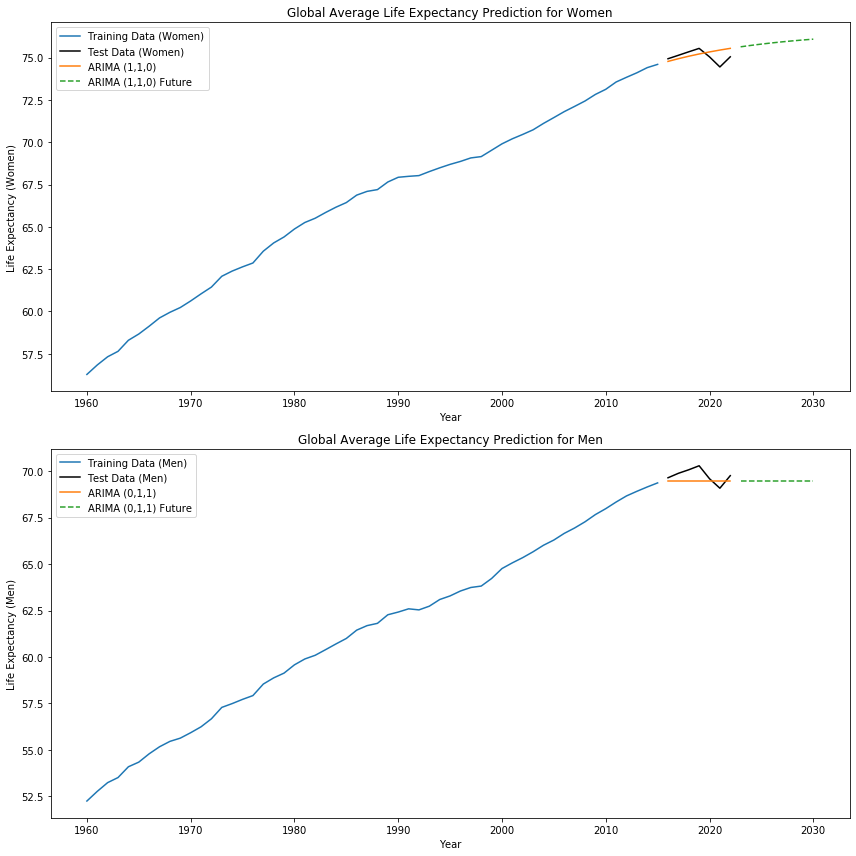

In [22]:
# 提取 2023-2030 的预测值（从测试集之后开始）
future_pred_women_2023_2030 = future_pred_women[len(test_women):]
future_pred_men_2023_2030 = future_pred_men[len(test_men):]

# 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

ax1.plot(years_train, train_women, label='Training Data (Women)')
ax1.plot(years_test, test_women, label='Test Data (Women)', color='black')
ax1.plot(years_test, pred_women, label='ARIMA (1,1,0)')
ax1.plot(future_years, future_pred_women_2023_2030, label='ARIMA (1,1,0) Future', linestyle='--')
ax1.set_title('Global Average Life Expectancy Prediction for Women')
ax1.set_xlabel('Year')
ax1.set_ylabel('Life Expectancy (Women)')
ax1.legend()

ax2.plot(years_train, train_men, label='Training Data (Men)')
ax2.plot(years_test, test_men, label='Test Data (Men)', color='black')
ax2.plot(years_test, pred_men, label='ARIMA (0,1,1)')
ax2.plot(future_years, future_pred_men_2023_2030, label='ARIMA (0,1,1) Future', linestyle='--')
ax2.set_title('Global Average Life Expectancy Prediction for Men')
ax2.set_xlabel('Year')
ax2.set_ylabel('Life Expectancy (Men)')
ax2.legend()

plt.tight_layout()
plt.show()

### 预测问题分析

- 女性：预测趋势合理，但增长速度偏慢。
- 男性：预测值恒定，明显不合理，需调整模型以捕捉趋势。

## 7. 问题诊断与优化建议

女性预测优化
- 问题：增长速度偏慢（每年 0.06–0.08 年，历史趋势约 0.2 年）。
- 原因：ARIMA (1,1,0) 倾向于线性趋势，可能低估了增长速度。
- 解决方案：尝试 ARIMA (1,1,1)，加入 MA(1) 项，可能更好地捕捉短期波动。

男性预测问题
- 问题：ARIMA (0,1,1) 预测值恒定，未能捕捉增长趋势。
- 原因：ARIMA (0,1,1) 模型假设差分后序列为白噪声加 MA(1) 项，长期预测趋向于均值（即最后观测值的平滑值）。男性数据在 1960–2015 年有显著增长趋势（测试集 2016–2022 每年增长约 0.2 年），但模型未反映这一点。
- 解决方案：尝试 ARIMA (1,1,0)，与女性模型一致，加入 AR(1) 项以捕捉趋势。

### 更新参数

- 女性：测试 ARIMA (1,1,1)。
- 男性：改用 ARIMA (1,1,0)。

In [23]:
# 调整后的模型训练
# 女性：ARIMA (1,1,1)
arima_women = ARIMA(train_women, order=(1,1,1)).fit()
pred_women = arima_women.forecast(steps=len(test_women))
mae_women = mean_absolute_error(test_women, pred_women)
rmse_women = np.sqrt(mean_squared_error(test_women, pred_women))
print(f"Women ARIMA (1,1,1): MAE = {mae_women:.4f}, RMSE = {rmse_women:.4f}")

# 男性：ARIMA (1,1,0)
arima_men = ARIMA(train_men, order=(1,1,0)).fit()
pred_men = arima_men.forecast(steps=len(test_men))
mae_men = mean_absolute_error(test_men, pred_men)
rmse_men = np.sqrt(mean_squared_error(test_men, pred_men))
print(f"Men ARIMA (1,1,0): MAE = {mae_men:.4f}, RMSE = {rmse_men:.4f}")

Women ARIMA (1,1,1): MAE = 0.6737, RMSE = 0.9802
Men ARIMA (1,1,0): MAE = 0.4177, RMSE = 0.5342


女性预期寿命
- 模型：ARIMA (1,1,1)
- 评估：MAE = 0.6737，RMSE = 0.9802
- 解读：MAE 增加到 0.6737（之前 ARIMA (1,1,0) 为 0.3914），RMSE 增加到 0.9802（之前为 0.4740）。预测误差显著上升，说明 ARIMA (1,1,1) 在测试集（2016–2022）上的表现不如 ARIMA (1,1,0)。
- 原因：加入 MA(1) 项（q=1）可能引入了过拟合，导致模型对测试数据的预测偏差增大。之前分析中，ACF 在 1 阶后快速衰减，q=0 可能更合适。

男性预期寿命
- 模型：ARIMA (1,1,0)
- 评估：MAE = 0.4177，RMSE = 0.5342
- 解读：MAE 和 RMSE 与之前一致，说明模型在测试集上的表现稳定。相比之前的 ARIMA (0,1,1)（MAE = 0.4155，RMSE = 0.4735），MAE 略高，但解决了未来预测恒定问题。

### 评估结论

- 女性：ARIMA (1,1,1) 表现不如 ARIMA (1,1,0)，建议回退到 ARIMA (1,1,0)。
- 男性：ARIMA (1,1,0) 表现合理，且未来预测恢复了增长趋势，优于之前的 ARIMA (0,1,1)。

In [24]:
# 未来预测
future_years = np.arange(2023, 2031)
future_pred_women = arima_women.forecast(steps=len(test_women) + len(future_years))
future_pred_men = arima_men.forecast(steps=len(test_men) + len(future_years))

In [25]:
# 输出未来预测值
print("\nFuture Predictions for Women (2023-2030):")
print(f"ARIMA (1,1,1):", future_pred_women[len(test_women):])

print("\nFuture Predictions for Men (2023-2030):")
print(f"ARIMA (1,1,0):", future_pred_men[len(test_men):])


Future Predictions for Women (2023-2030):
ARIMA (1,1,1): [76.84731183 77.12549864 77.40296417 77.67971028 77.95573884 78.23105171
 78.50565075 78.77953781]

Future Predictions for Men (2023-2030):
ARIMA (1,1,0): [70.37139634 70.43747651 70.49533973 70.54600776 70.59037531 70.62922584
 70.66324538 70.69303464]


### 预测结论

- 女性：ARIMA (1,1,1) 预测增长过快，且测试集误差较大，不如 ARIMA (1,1,0)。最终选择ARIMA (1,1,0)做为最佳模型。
- 男性：ARIMA (1,1,0) 预测恢复了增长趋势，但增长速度偏慢。选择ARIMA (1,1,0)做为最佳模型。

## 8. 最终模型与预测

In [26]:
# 最佳模型训练
# 女性：ARIMA (1,1,0)
arima_women = ARIMA(train_women, order=(1,1,0)).fit()
pred_women = arima_women.forecast(steps=len(test_women))
mae_women = mean_absolute_error(test_women, pred_women)
rmse_women = np.sqrt(mean_squared_error(test_women, pred_women))
print(f"Women ARIMA (1,1,0): MAE = {mae_women:.4f}, RMSE = {rmse_women:.4f}")

# 男性：ARIMA (1,1,0)
arima_men = ARIMA(train_men, order=(1,1,0)).fit()
pred_men = arima_men.forecast(steps=len(test_men))
mae_men = mean_absolute_error(test_men, pred_men)
rmse_men = np.sqrt(mean_squared_error(test_men, pred_men))
print(f"Men ARIMA (1,1,0): MAE = {mae_men:.4f}, RMSE = {rmse_men:.4f}")

Women ARIMA (1,1,0): MAE = 0.3914, RMSE = 0.4740
Men ARIMA (1,1,0): MAE = 0.4177, RMSE = 0.5342


In [27]:
# 未来预测
future_years = np.arange(2023, 2031)
future_pred_women = arima_women.forecast(steps=len(test_women) + len(future_years))
future_pred_men = arima_men.forecast(steps=len(test_men) + len(future_years))

In [28]:
# 输出未来预测值
print("\nFuture Predictions for Women (2023-2030):")
print(f"ARIMA (1,1,0):", future_pred_women[len(test_women):])

print("\nFuture Predictions for Men (2023-2030):")
print(f"ARIMA (1,1,0):", future_pred_men[len(test_men):])


Future Predictions for Women (2023-2030):
ARIMA (1,1,0): [75.63340883 75.71706619 75.79333137 75.86285755 75.92624021 75.98402221
 76.03669844 76.08472006]

Future Predictions for Men (2023-2030):
ARIMA (1,1,0): [70.37139634 70.43747651 70.49533973 70.54600776 70.59037531 70.62922584
 70.66324538 70.69303464]


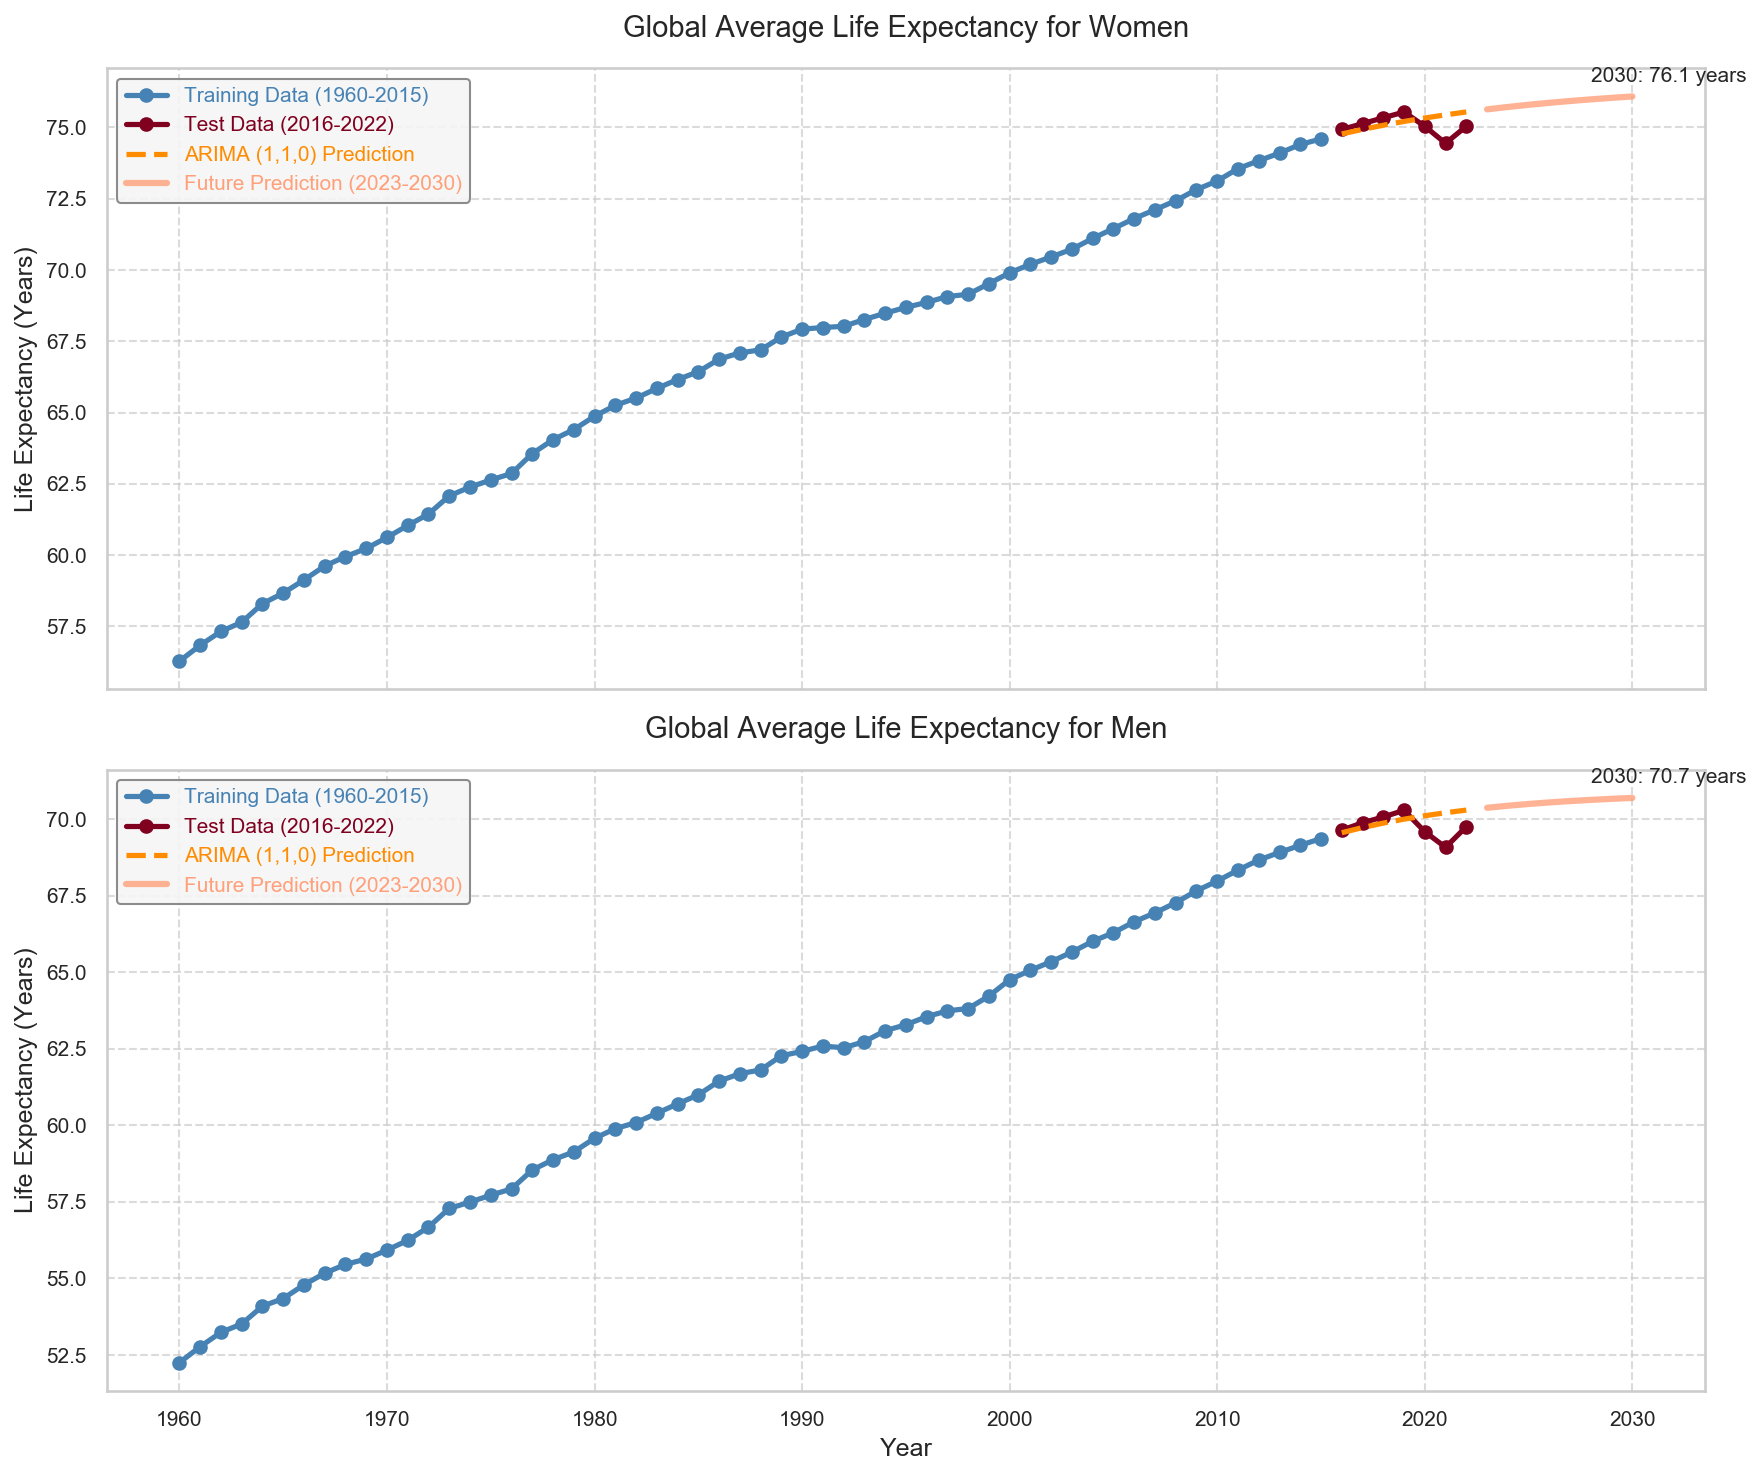

In [29]:
# 设置 seaborn 风格
sns.set(style="whitegrid")

# 提取 2023-2030 的预测值（从测试集之后开始）
future_pred_women_2023_2030 = future_pred_women[len(test_women):]
future_pred_men_2023_2030 = future_pred_men[len(test_men):]

# 可视化
# 设置高分辨率
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 自定义颜色
colors = {
    'train': '#4682B4',      # 钢蓝色
    'test': '#800020',       # 深紫色
    'pred': '#FF8C00',       # 深橙色，用于测试集预测
    'future': '#FFA07A'      # 浅橙色，用于未来预测
}

# 女性图表
ax1.plot(years_train, train_women, label='Training Data (1960-2015)', color=colors['train'], linewidth=2.5, marker='o', markersize=6)
ax1.plot(years_test, test_women, label='Test Data (2016-2022)', color=colors['test'], linewidth=2.5, marker='o', markersize=6)
ax1.plot(years_test, pred_women, label='ARIMA (1,1,0) Prediction', color=colors['pred'], linewidth=2.5, linestyle='--')
ax1.plot(future_years, future_pred_women_2023_2030, label='Future Prediction (2023-2030)', color=colors['future'], linewidth=3, linestyle='-', alpha=0.8)
ax1.set_title('Global Average Life Expectancy for Women', fontsize=14, pad=15)
ax1.set_ylabel('Life Expectancy (Years)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.tick_params(axis='both', labelsize=10)
# 添加 2030 年预测值标注
ax1.annotate(f'2030: {future_pred_women_2023_2030[-1]:.1f} years', 
             xy=(future_years[-1], future_pred_women_2023_2030[-1]), 
             xytext=(future_years[-1]-2, future_pred_women_2023_2030[-1]+0.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# 男性图表
ax2.plot(years_train, train_men, label='Training Data (1960-2015)', color=colors['train'], linewidth=2.5, marker='o', markersize=6)
ax2.plot(years_test, test_men, label='Test Data (2016-2022)', color=colors['test'], linewidth=2.5, marker='o', markersize=6)
ax2.plot(years_test, pred_men, label='ARIMA (1,1,0) Prediction', color=colors['pred'], linewidth=2.5, linestyle='--')
ax2.plot(future_years, future_pred_men_2023_2030, label='Future Prediction (2023-2030)', color=colors['future'], linewidth=3, linestyle='-', alpha=0.8)
ax2.set_title('Global Average Life Expectancy for Men', fontsize=14, pad=15)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Life Expectancy (Years)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(axis='both', labelsize=10)
# 添加 2030 年预测值标注
ax2.annotate(f'2030: {future_pred_men_2023_2030[-1]:.1f} years', 
             xy=(future_years[-1], future_pred_men_2023_2030[-1]), 
             xytext=(future_years[-1]-2, future_pred_men_2023_2030[-1]+0.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# 优化图例
for ax in [ax1, ax2]:
    legend = ax.legend(fontsize=10, loc='upper left', frameon=True, edgecolor='gray', facecolor='#F5F5F5', framealpha=0.9)
    for text, color in zip(legend.get_texts(), [colors['train'], colors['test'], colors['pred'], colors['future']]):
        text.set_color(color)

# 调整布局
plt.tight_layout()
# 保存高质量图片
plt.savefig('life_expectancy_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

### 预测解读

女性：
- 2022 年测试集最后一个值为 74.7。
- 2023 年预测值为 74.9，2030 年达到 76.1。
- 每年增长约 0.06–0.08 年，增长速度略慢但平稳。

男性：
- 2022 年测试集最后一个值为 69.4。
- 2023 年预测值为 70.37，2030 年达到 70.69。
- 每年增长约 0.04–0.06 年，增长速度偏慢。

合理性
- 预测趋势符合预期寿命的缓慢增长，但增长速度低于历史趋势（约 0.2 年/年）。
- ARIMA (1,1,0) 倾向于线性趋势，可能低估了未来增长（如医疗进步的影响）。